# LSST Workshop 2026 — Autoencoders
## Hands-on problem set: from PCA to discovery (90 min)

**Logistics.** Work in Colab (`File → Save a copy in Drive` first). CPU is fine; a GPU
(`Runtime → Change runtime type → T4`) just makes everything instant. Working in pairs is
encouraged. Cells marked **`# TODO`** are yours to fill; a solutions notebook exists if you
get stuck — but commit to an attempt first.

**The one rule: predict before you run.** Every section asks you to commit to a prediction
before executing the cell. The exercises only teach if you put a stake in the ground —
being confidently wrong is far more instructive than being vaguely right.

| Part | Topic | Time |
|---|---|---|
| 1 | Build a vanilla AE, then rebuild its **loss function** the way a survey pipeline needs it | 20 min |
| 2 | A zoo of AEs for three research problems (denoising, generation, discovery) | 25 min |
| 3 | Bake-off: same architecture, three training schemes, three tests | 15 min |
| ★ | **Challenge:** find the hidden spectroscopic binaries (open-ended) | 30 min + take-home |

Everything trains in seconds-to-a-minute. If a cell runs longer than ~2 min on CPU, stop it and ask.


In [1]:
# Setup — run once. (Colab has torch & sklearn preinstalled.)
import torch, torch.nn as nn, torch.nn.functional as F
import numpy as np, matplotlib.pyplot as plt
torch.manual_seed(0); np.random.seed(0)
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print('device:', device)

device: cuda


---
## The data: a pocket spectroscopic survey

We generate continuum-normalized optical spectra (4000–7000 Å, 300 pixels) the way a
forward model would: a Planck continuum, Balmer lines (deep for hot stars) and metal lines
(deep for cool stars), Doppler-shifted and broadened. Each star is fully described by
**three physical parameters**:

| symbol | meaning | effect on the spectrum |
|---|---|---|
| $T$ | effective temperature [K] | continuum slope + which lines are deep |
| $rv$ | radial velocity [km/s] | Doppler shift of *every* line |
| $w$ | broadening [Å] | line widths (rotation + instrument) |

Why synthetic? Because here we **know the ground truth** — so for once you can check
whether your latent space actually learned the physics. The arrays are shaped exactly like
what SDSS/LAMOST/DESI pipelines hand you (flux now; inverse-variance and masks in Part 1.2),
so everything below transfers.

One practical note baked into the last lines below: we **standardize each pixel** (zero
mean, unit variance, fit on the training archive only) and let the networks work in
normalized space. $T$ alone drives ~97% of the raw flux variance; without standardization,
gradient descent spends its entire budget on the continuum and never learns the velocity
information hiding in the line flanks. Keep that asymmetry in mind — it returns with a
vengeance in Part 1.1.

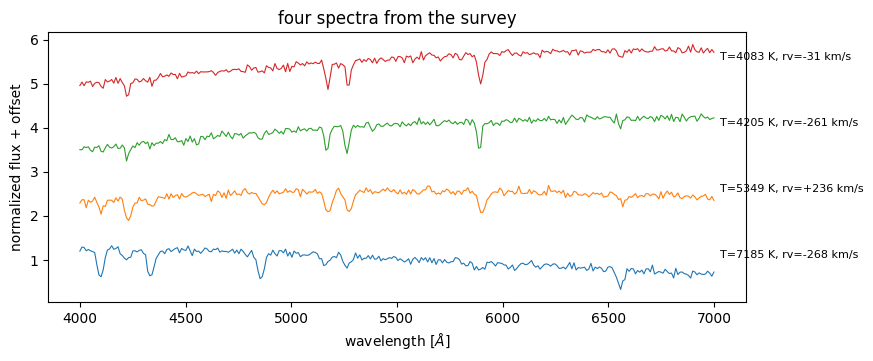

In [2]:
# ---- forward model -------------------------------------------------------
C_KMS  = 299792.458
N_PIX  = 300
WAVE   = np.linspace(4000., 7000., N_PIX)                  # Angstrom
BALMER = np.array([4101.7, 4340.5, 4861.3, 6562.8])        # Hd, Hg, Hb, Ha
METALS = np.array([4226.7, 5172.7, 5269.5, 5895.9])        # CaI, MgI, FeI, NaD

def continuum(T):
    lam = WAVE * 1e-10
    B = 1.0 / (lam**5 * (np.exp(1.4388e-2/(lam*T[:, None])) - 1.0))   # Planck
    return B / B.mean(1, keepdims=True)

def lines(T, rv, w):
    # Gaussian absorption lines; Balmer depths peak for hot stars, metals for cool
    shift   = 1.0 + rv[:, None]/C_KMS
    depth_b = 0.7*np.exp(-0.5*((T - 9500.)/3000.)**2)[:, None]
    depth_m = 0.6*np.exp(-0.5*((T - 4000.)/2200.)**2)[:, None]
    A = np.zeros((len(T), N_PIX))
    for l0 in BALMER: A += depth_b*np.exp(-0.5*((WAVE - l0*shift)/w[:, None])**2)
    for l0 in METALS: A += depth_m*np.exp(-0.5*((WAVE - l0*shift)/w[:, None])**2)
    return A

def make_survey(n, rng, emission=False, sb2=False):
    T, rv, w = rng.uniform(4000., 9000., n), rng.uniform(-400., 400., n), rng.uniform(9., 18., n)
    A = lines(T, rv, w)
    if sb2:                                   # double-lined spectroscopic binary
        dv = rng.choice([-1, 1], n)*rng.uniform(700., 1200., n)
        A  = 0.5*(A + lines(T, rv + dv, w))
    if emission: A = -A                       # emission-line interloper
    return (continuum(T)*(1.0 - A)).astype(np.float32), {'T': T, 'rv': rv, 'w': w}

SIGMA0 = 0.05                                              # survey noise level
rng = np.random.default_rng(0)
X_clean, params = make_survey(3000, rng)                   # the 'archive'
X_obs = (X_clean + SIGMA0*rng.normal(size=X_clean.shape)).astype(np.float32)

# ---- per-pixel standardization (fit on the archive ONLY -- it's the training set) ----
MU, SD = X_obs.mean(0), X_obs.std(0)
nrm  = lambda X: ((X - MU)/SD).astype(np.float32)          # physical -> normalized
phys = lambda Xn: Xn*SD + MU                               # normalized -> physical
XnO_t = torch.tensor(nrm(X_obs),   device=device)          # networks live in this space
XnC_t = torch.tensor(nrm(X_clean), device=device)
SD_t  = torch.tensor(SD, device=device)

plt.figure(figsize=(9, 3.5))
for i in range(4):
    plt.plot(WAVE, X_obs[i] + 1.5*i, lw=.8)
    plt.text(7030, 1.05 + 1.5*i, f"T={params['T'][i]:.0f} K, rv={params['rv'][i]:+.0f} km/s", fontsize=8)
plt.xlabel('wavelength [$\\AA$]'); plt.ylabel('normalized flux + offset')
plt.title('four spectra from the survey'); plt.show()

test

---
## Part 1 — Build it (20 min)

### 1.1 A vanilla autoencoder

**Predict first.** This dataset is generated by *exactly three* physical parameters.
Before you run anything: (i) what bottleneck dimension $d$ should suffice, and (ii) where
will the elbow be in the reconstruction-error-vs-$d$ curve? Write your guess down.

**`# TODO`**: fill in the encoder/decoder: one hidden ReLU layer each side, no activation
after the final layer (normalized flux is unbounded).

My prediction:
- the bottleneck dimension is
- the elbow will happen at dimension 2

In [4]:
def mlp(sizes, act=nn.ReLU):
    L = []
    for i in range(len(sizes) - 1):
        L.append(nn.Linear(sizes[i], sizes[i+1]))
        if i < len(sizes) - 2: L.append(act())
    return nn.Sequential(*L)

class AE(nn.Module):
    def __init__(self, d, n_in=N_PIX, h=128):
        super().__init__()

        # TODO: encoder n_in -> h -> d and the mirror decoder d -> h -> n_in.
        #       Use the mlp() helper. (mlp puts ReLU between layers, none at the end.)

        self.enc = mlp([n_in, h, d])  # TODO
        self.dec = mlp([d, h, n_in])  # TODO

    def forward(self, x): return self.dec(self.enc(x))

def train(model, tensors, loss_fn, steps=2500, bs=256, lr=2e-3):
    # generic minibatch trainer: loss_fn(model, *batch) -> scalar
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    n = tensors[0].shape[0]
    for _ in range(steps):
        idx = torch.randint(0, n, (bs,), device=device)
        opt.zero_grad()
        loss = loss_fn(model, *[t[idx] for t in tensors])
        loss.backward(); opt.step()
    return loss.item()

mse = lambda m, x: ((m(x) - x)**2).mean()

def err_physical(model, Xn_in, X_target):
    # error in PHYSICAL flux units, against any target (clean truth, if you have it)
    with torch.no_grad():
        rec = phys(model(Xn_in).cpu().numpy())
    return ((rec - X_target)**2).mean()

ae4 = AE(d=4).to(device)
train(ae4, (XnO_t,), mse)
print(f'd=4   error vs observed: {err_physical(ae4, XnO_t, X_obs):.5f}   (cannot beat sigma^2 = {SIGMA0**2:.4f})')
print(f'd=4   error vs CLEAN:    {err_physical(ae4, XnO_t, X_clean):.5f}  <- synthetic-data privilege: truth is known')

d=4   error vs observed: 0.00246   (cannot beat sigma^2 = 0.0025)
d=4   error vs CLEAN:    0.00013  <- synthetic-data privilege: truth is known


d= 1   error vs clean = 0.00083
d= 2   error vs clean = 0.00021
d= 3   error vs clean = 0.00010
d= 4   error vs clean = 0.00012
d= 8   error vs clean = 0.00020


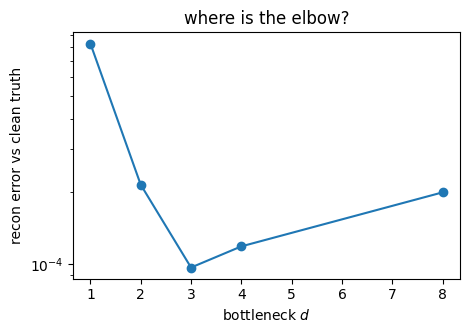

In [5]:
# Sweep the bottleneck. Check your elbow prediction.
dims, errs = [1, 2, 3, 4, 8], []
for d_ in dims:
    m = AE(d=d_).to(device)
    train(m, (XnO_t,), mse)
    errs.append(err_physical(m, XnO_t, X_clean))
    print(f'd={d_:2d}   error vs clean = {errs[-1]:.5f}')
plt.figure(figsize=(5, 3.2))
plt.plot(dims, errs, 'o-'); plt.yscale('log')
plt.xlabel('bottleneck $d$'); plt.ylabel('recon error vs clean truth')
plt.title('where is the elbow?'); plt.show()

**Takeaway.** The error drops steeply up to $d=3$ — the number of physical parameters in
the forward model — and is flat after. The bottleneck sweep is a (crude but real)
*intrinsic-dimensionality estimator*: on real survey data, where you don't know the answer,
this same plot is how you'd ask "how many effective degrees of freedom does my object
class have?"

**Check yourself:** (i) why is $d=1$ not catastrophically bad? (Hint: which single parameter
buys the most flux variance?) (ii) Try this sweep *without* the standardization — the elbow
all but vanishes, because $rv$ and $w$ live in <1% of the raw variance. **Variance is not
importance** — the scientifically interesting parameters are often the low-variance ones.
(iii) What happens to the elbow if we add metallicity to the forward model?

### 1.2 Custom loss: what the pipeline actually hands you

Nobody hands you clean flux. A real reduction pipeline delivers **three arrays per
spectrum**: the flux $x$, a per-pixel noise estimate $\sigma$, and a quality mask $m$
(0 = dead pixel / cosmic ray / saturated sky line). Plain MSE silently assumes every pixel
is equally trustworthy — and bad pixels are *wrong by a lot*, so they dominate the gradient.
(Standardization can't save you here: it knows each pixel's average scale, but not that
*this* pixel in *this* exposure is garbage.)

The fix is to make the loss the (negative log) **likelihood** of the data:

$$\mathcal{L}_{\chi^2} \;=\; \frac{1}{\sum_{ij} m_{ij}}\sum_{ij} m_{ij}\,
\frac{(\hat x_{ij}-x_{ij})^2}{\sigma_{ij}^2}$$

**Predict first.** We'll train two *identical* AEs on the same messy data — one with MSE,
one with masked $\chi^2$. Where will their reconstructions differ most: the good pixels,
the noisy sky bands, or the dead pixels? And what will the $\chi^2$ model output *in* the
dead regions, where it has never been graded?

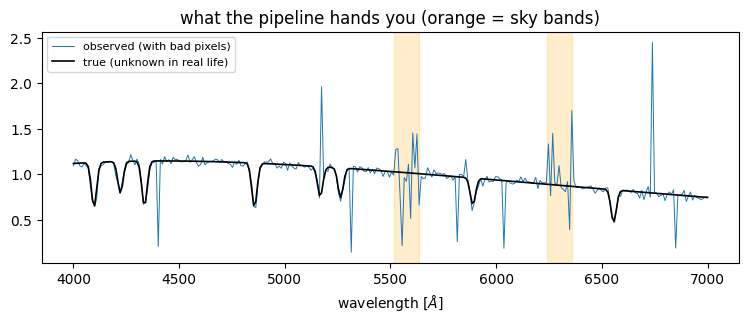

In [7]:
# A messier survey: heteroscedastic noise + bad pixels (kept in PHYSICAL units --
# the sigma array does the weighting that standardization did in Part 1.1)
rng2 = np.random.default_rng(1)
X2_clean, p2 = make_survey(3000, rng2)
sig_map = np.full(X2_clean.shape, 0.03, dtype=np.float32)
for l_sky in (5577., 6300.):                              # [OI] airglow residual bands
    sig_map[:, np.abs(WAVE - l_sky) < 60.] = 0.30
mask = (rng2.random(X2_clean.shape) > 0.03).astype(np.float32)   # 3% dead pixels
X2 = (X2_clean + sig_map*rng2.normal(size=X2_clean.shape)).astype(np.float32)
X2[mask == 0] = rng2.uniform(0., 3., int((mask == 0).sum()))     # garbage where dead

X2_t  = torch.tensor(X2, device=device);     X2c_t = torch.tensor(X2_clean, device=device)
sig_t = torch.tensor(sig_map, device=device); msk_t = torch.tensor(mask, device=device)

plt.figure(figsize=(9, 3))
plt.plot(WAVE, X2[0], lw=.7, label='observed (with bad pixels)')
plt.plot(WAVE, X2_clean[0], 'k', lw=1.2, label='true (unknown in real life)')
for l_sky in (5577., 6300.): plt.axvspan(l_sky-60, l_sky+60, color='orange', alpha=.2)
plt.legend(fontsize=8); plt.xlabel('wavelength [$\\AA$]')
plt.title('what the pipeline hands you (orange = sky bands)'); plt.show()

In [15]:
def chi2_loss(m, x, sig, msk):
    xhat = m(x)
    l =  torch.log10(torch.sum(msk*(xhat - x)**2/sig**2)/(1/torch.sum(msk)))
    # TODO: masked inverse-variance loss:
    #   sum over all pixels of  msk * (xhat - x)^2 / sig^2 ,  divided by msk.sum()

    return l # TODO

ae_mse  = AE(d=4).to(device); train(ae_mse,  (X2_t,), mse, steps=2000, lr=1e-3)
ae_chi2 = AE(d=4).to(device); train(ae_chi2, (X2_t, sig_t, msk_t), chi2_loss, steps=2000, lr=1e-3)

sky_t = torch.tensor((np.abs(WAVE-5577.) < 60.) | (np.abs(WAVE-6300.) < 60.), device=device)
def report(model, name):
    with torch.no_grad():
        e = (model(X2_t) - X2c_t)**2          # graded against the clean truth
    good = (e[:, ~sky_t]*msk_t[:, ~sky_t]).sum()/msk_t[:, ~sky_t].sum()
    dead = (e*(1 - msk_t)).sum()/(1 - msk_t).sum()
    print(f'{name:14s} good px: {good:.5f}   sky bands: {e[:, sky_t].mean():.5f}   dead px: {dead:.5f}')
report(ae_mse,  'MSE loss');  report(ae_chi2, 'masked chi2')

MSE loss       good px: 0.00131   sky bands: 0.00894   dead px: 0.00309
masked chi2    good px: 0.00046   sky bands: 0.00063   dead px: 0.00085


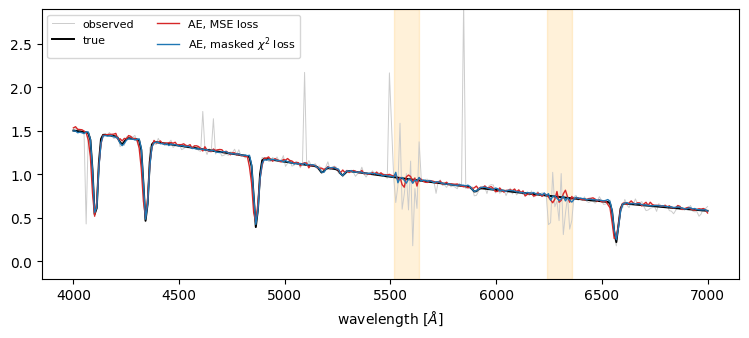

In [16]:
# One spectrum, both reconstructions
i = 3
with torch.no_grad():
    rm = ae_mse(X2_t[i:i+1])[0].cpu(); rc = ae_chi2(X2_t[i:i+1])[0].cpu()
plt.figure(figsize=(9, 3.5))
plt.plot(WAVE, X2[i], color='0.8', lw=.7, label='observed')
plt.plot(WAVE, X2_clean[i], 'k', lw=1.4, label='true')
plt.plot(WAVE, rm, 'C3', lw=1, label='AE, MSE loss')
plt.plot(WAVE, rc, 'C0', lw=1, label='AE, masked $\\chi^2$ loss')
for l_sky in (5577., 6300.): plt.axvspan(l_sky-60, l_sky+60, color='orange', alpha=.15)
plt.ylim(-0.2, 2.9); plt.legend(fontsize=8, ncol=2); plt.xlabel('wavelength [$\\AA$]'); plt.show()

**Takeaway.** The $\chi^2$ model *inpaints* the dead pixels and sky bands: it was never
graded there, so it fills them with what the learned manifold says should be there. That is
not a parlor trick — it is exactly how missing data, telluric bands, and chip gaps are
handled in modern spectral analysis, and it's the same idea behind masked-pixel pretraining
of large vision models. **The loss function is the noise model.** Change one, you've changed
the other. Keep this in mind for the VAE — its reconstruction term is this same likelihood.

---
## Part 2 — A zoo of autoencoders for three research problems (25 min)

Three things astronomers actually do with autoencoders:

1. **Denoise.** You have a deep, high-S/N archive (here: `X_clean`) and a new shallow survey
   at much lower S/N. → *Denoising AE (DAE).*
2. **Compress & generate.** You want a low-dimensional, *samplable* model of the population —
   for forward-modeling, priors, survey simulation. → *Variational AE (VAE).*
3. **Discover.** You want to flag objects that don't belong to the population at all.
   → reconstruction error as an anomaly score (Part 3 and the Challenge).

### 2.1 Denoising AE

**Predict first.** The DAE sees a freshly corrupted input every step but is graded against
the clean target. Why is this not cheating, and why should it beat the vanilla AE on noisy
input even though both have the identical architecture? One sentence each.

Prediction:
- IDK
- Does better because it sees the clean data.

In [23]:
SIGMA_LO = 0.20                   # the new shallow survey: 4x noisier
def dae_loss(m, xnc):
    # corrupt with PHYSICAL noise sigma_lo; in normalized space that's sigma_lo/SD per pixel
    noisy = xnc + (SIGMA_LO/SD_t)*torch.randn_like(xnc)
    # TODO: reconstruct the CLEAN xnc from the noisy input (one line)
    recon = m(noisy)



    return ((recon - xnc)**2).mean() # TODO

dae = AE(d=4).to(device)
train(dae, (XnC_t,), dae_loss, steps=3000)
print('DAE trained on noisy->clean pairs.')

DAE trained on noisy->clean pairs.


### 2.2 Variational AE — your $\chi^2$ loss grows a prior

The VAE loss is your Part 1.2 loss plus one new term:

$$\mathcal{L}_{\rm VAE} = \underbrace{\sum_j \frac{(\hat x_j - x_j)^2}{2\sigma_{n,j}^2}}_{\text{your } \chi^2/2 \text{ — Gaussian NLL}}
\;+\; \beta\,\underbrace{\tfrac{1}{2}\sum_i\left(\mu_i^2 + \sigma_i^2 - \log\sigma_i^2 - 1\right)}_{\mathrm{KL}\left(q(z|x)\,\|\,N(0,I)\right)}$$

where $\sigma_{n,j} = \sigma_0/\mathrm{SD}_j$ is the survey noise in normalized units —
*the same inverse-variance weighting you built in 1.2*. The KL term pins the latent
distribution to $N(0,I)$, which is what makes the latent space **samplable**.
We use $\beta=4$; you'll explore why in the finish-early exercises.
**`# TODO`**: implement the KL term (closed form above).

**Predict first.** After training, we will draw $z\sim\mathcal{N}(0,I)$ and push the *same*
$z$ through (a) the vanilla AE's decoder and (b) the VAE's decoder. Describe what each will
produce, and why.

Prediction: VAE would draw synthetic data representative from the population
Vanilla will draw

In [ ]:
class VAE(nn.Module):
    def __init__(self, d=4, n_in=N_PIX, h=128):
        super().__init__()
        self.enc = mlp([n_in, h, 2*d])           # outputs [mu | logvar]
        self.dec = mlp([d, h, n_in])
        self.d = d
    def forward(self, x):
        h = self.enc(x); mu, logvar = h[:, :self.d], h[:, self.d:]
        z = mu + (0.5*logvar).exp()*torch.randn_like(mu)   # reparameterization
        return self.dec(z), mu, logvar

ivar = (SD_t/SIGMA0)**2                          # 1/sigma_n^2, per pixel
vae, beta = VAE(d=4).to(device), 4.0
opt = torch.optim.Adam(vae.parameters(), lr=1e-3)
for step in range(5000):
    idx = torch.randint(0, len(XnO_t), (256,), device=device)
    x = XnO_t[idx]
    opt.zero_grad()
    xhat, mu, logvar = vae(x)
    recon = ((xhat - x)**2 * ivar / 2).sum(1).mean()             # Gaussian NLL = chi2/2
    # TODO: KL term: 0.5 * sum_i( mu^2 + sigma^2 - log sigma^2 - 1 ), mean over the batch
    #       (hint: sigma^2 = logvar.exp(); log sigma^2 = logvar)
    kl1 = 0.5*torch.sum*
    kl = None  # TODO
    (recon + beta*kl).backward(); opt.step()
print(f'VAE: recon={recon.item():.1f}   kl={kl.item():.2f}  (nats of information in z)')

In [ ]:
# Same z ~ N(0,I) through both decoders. Which one runs a survey simulator?
with torch.no_grad():
    z = torch.randn(4, 4, device=device)
    s_van = phys(ae4.dec(z).cpu().numpy())
    s_vae = phys(vae.dec(z).cpu().numpy())
fig, ax = plt.subplots(1, 2, figsize=(11, 3.4), sharey=True)
for i in range(4):
    ax[0].plot(WAVE, s_van[i] + 1.3*i, lw=.8); ax[1].plot(WAVE, s_vae[i] + 1.3*i, lw=.8)
ax[0].set_title('vanilla AE decoder on $z\\sim\\mathcal{N}(0,I)$')
ax[1].set_title('VAE decoder on the same $z$')
for a in ax: a.set_xlabel('wavelength [$\\AA$]')
plt.show()
# Check: VAE draws should look like plausible survey members -- Planck-ish continuum,
# absorption lines at consistent (shifted) positions. Vanilla draws are off-manifold.

---
## Part 3 — The bake-off (15 min)

Three models. **Identical architecture** (`300 → 128 → 4 → 128 → 300`). The only difference
is how each was *trained*. Three tests on a fresh test set:

| Test | Question |
|---|---|
| 1. Denoise | reconstruct clean truth from $\sigma=0.2$ input |
| 2. Physics | linear probe: latent $\to$ ($T$, $rv$, $w$), held-out $R^2$ |
| 3. Discover | flag emission-line interlopers by reconstruction error (AUC) |

**Predict first — this is the one that counts.** Write an actual 3×3 table on paper:
rows = {vanilla, DAE, VAE}, columns = {denoise, physics, discover}; put your predicted
*rank* in each cell. Then run.

In [ ]:
def embed(m, x):  # latent code (mu for the VAE)
    return m.enc(x)[:, :m.d] if isinstance(m, VAE) else m.enc(x)
def recon(m, x):
    return m.dec(embed(m, x))

rng3 = np.random.default_rng(3)
Xte_clean, pte = make_survey(1000, rng3)
Xte_noisy = (Xte_clean + SIGMA_LO*rng3.normal(size=Xte_clean.shape)).astype(np.float32)
Xte_n = torch.tensor(nrm(Xte_noisy), device=device)        # normalized, like the models expect

models = {'vanilla AE': ae4, 'DAE': dae, 'VAE': vae}
print('Test 1 -- denoising (error vs clean truth, physical units):')
with torch.no_grad():
    for name, m in models.items():
        rec = phys(recon(m, Xte_n).cpu().numpy())
        print(f'   {name:11s} {((rec - Xte_clean)**2).mean():.5f}')
    print(f'   {"do nothing":11s} {((Xte_noisy - Xte_clean)**2).mean():.5f}')

In [ ]:
def probe_r2(Z, y, ntr=500):
    # honest linear probe: fit on first ntr, score on the rest
    A = np.c_[Z, np.ones(len(Z))]
    coef, *_ = np.linalg.lstsq(A[:ntr], y[:ntr], rcond=None)
    resid = y[ntr:] - A[ntr:] @ coef
    return 1 - (resid**2).sum()/((y[ntr:] - y[ntr:].mean())**2).sum()

# probe at the survey's own noise level (sigma0), not the shallow survey's
Xte_s0 = torch.tensor(nrm(Xte_clean + SIGMA0*rng3.normal(size=Xte_clean.shape)), device=device)
print('Test 2 -- physics in the latent (held-out linear-probe R^2):')
print(f'   {"model":11s} {"T":>6s} {"rv":>6s} {"w":>6s}')
with torch.no_grad():
    for name, m in models.items():
        Z = embed(m, Xte_s0).cpu().numpy()
        print(f'   {name:11s} ' + ' '.join(f'{probe_r2(Z, pte[k]):6.2f}' for k in ('T', 'rv', 'w')))
# Now re-run with Xte_n (the sigma=0.2 input). Which parameter's R^2 collapses first,
# and why? (Think about how rv enters the spectrum: a sub-pixel *shift*, read from
# line flanks -- exactly the pixels noise corrupts first.)

In [ ]:
from sklearn.metrics import roc_auc_score
Xan, _ = make_survey(100, rng3, emission=True)            # emission-line interlopers
X_all  = np.vstack([Xte_clean, Xan])
X_all  = (X_all + SIGMA0*rng3.normal(size=X_all.shape)).astype(np.float32)
y_anom = np.r_[np.zeros(1000), np.ones(100)]
Xall_t = torch.tensor(nrm(X_all), device=device)

print('Test 3 -- emission-line interlopers (recon-error AUC):')
with torch.no_grad():
    for name, m in models.items():
        s = ((recon(m, Xall_t) - Xall_t)**2).mean(1).cpu().numpy()
        print(f'   {name:11s} AUC = {roc_auc_score(y_anom, s):.3f}')
with torch.no_grad():
    s = ((recon(dae, Xall_t) - Xall_t)**2).mean(1).cpu().numpy()
plt.figure(figsize=(5, 3))
plt.hist(s[y_anom == 0], bins=40, alpha=.6, density=True, label='normal stars')
plt.hist(s[y_anom == 1], bins=40, alpha=.6, density=True, label='emission-line')
plt.xlabel('reconstruction error (normalized units)'); plt.legend(fontsize=8)
plt.title('anomaly score (DAE)'); plt.show()

**Bake-off debrief.** Compare the table you wrote down with the numbers. The headline:
*the architecture never changed.* The DAE wins denoising because denoising **is its training
objective**; the VAE is the only one whose latent you can sample; all three flag emission-line
objects easily because those interlopers are loudly off-manifold. In an ML-for-astro paper,
the sentence "we used an autoencoder" is nearly information-free — the loss function and
training scheme are the actual experiment design. Carry that into the challenge, where the
anomalies will *not* be loud.

---
## ★ Challenge — The hidden binaries (open-ended, ~30 min; finish as take-home)

A new batch of **3,000 spectra** just came off the telescope. Hidden among them, about
**2% are double-lined spectroscopic binaries (SB2s)**: two stars in a tight orbit, two
velocity systems — so *every absorption line is doubled*, with splittings of 700–1200 km/s.
(Splitting exaggerated relative to typical real SB2s so it's resolvable at our pixel scale.)
These are dynamically precious objects. **You have no labels.**

**Your task: build a detector.** Produce `scores` (length 3000, higher = more suspicious)
and call `evaluate_detector(scores)`. The referee reports AUC and precision@60.
**You get 3 referee calls total** — it is a referee, not a validation set. Spend them
deliberately.

**(a) Baseline (10 min).** Score by reconstruction error from one of your Part 2 models.
Spend referee call #1.

**(b) Beat it (15+ min).** Some directions — *not* exhaustive, and combinations of z-scored
signals are fair game: SB2 residuals are *coherent across neighboring pixels* while photon
noise is not — is there a one-line statistic for that? Latent-space novelty w.r.t. the
archive (e.g., Mahalanobis distance — careful, this one can backfire; knowing *why* is worth
as much as a good score). Residual power only at expected line locations. Ensembles and
disagreement.

**(c) The capacity trap (5 min).** In real life you may have no clean archive — so train a
fresh AE *directly on the contaminated challenge batch* and use its reconstruction error.
Try `d=4` and `d=32`, short and long training. **Predict before each referee call**: which
direction does each knob push the AUC, and why? *(This is the deepest question in the
problem set.)*

**(d) Open question — no code, one paragraph.** You're about to run your detector on
$10^8$ spectra from SDSS-V/4MOST/DESI, where there is no guaranteed-clean training set.
Discuss **two** of:
  (i) what does "anomalous" mean when the training set is itself contaminated?
  (ii) in practice, anomaly detectors rediscover *instrument artifacts* first — cosmic rays,
  sky-subtraction failures, dichroic glitches. How do you make yours find astrophysics instead?
  (iii) reconstruction error and latent-space likelihood can disagree. Construct an object
  that fools one but not the other. Which failure mode is scientifically more dangerous?
  (iv) you can afford follow-up spectra for 100 candidates. Is AUC even the right metric?
  (After answering, look at what long training did to precision@60 in part (c).)

In [ ]:
# The challenge batch. The referee holds the secret labels -- DO NOT touch _y_secret.
rng_ch = np.random.default_rng(2026)
_Xn, _ = make_survey(2940, rng_ch)
_Xb, _ = make_survey(60, rng_ch, sb2=True)
X_ch = np.vstack([_Xn, _Xb]); _y_secret = np.r_[np.zeros(2940), np.ones(60)]
_sh = rng_ch.permutation(3000); X_ch, _y_secret = X_ch[_sh], _y_secret[_sh]
X_ch = (X_ch + SIGMA0*rng_ch.normal(size=X_ch.shape)).astype(np.float32)
Xch_t = torch.tensor(nrm(X_ch), device=device); del _Xn, _Xb

_calls = [0]
def evaluate_detector(scores):
    scores = np.asarray(scores).ravel(); assert scores.shape == (3000,)
    if _calls[0] >= 3: print('Referee: no calls left. Write up what you have.'); return
    _calls[0] += 1
    auc = roc_auc_score(_y_secret, scores)
    top = np.argsort(scores)[::-1][:60]
    print(f'[referee {_calls[0]}/3]   AUC = {auc:.3f}   precision@60 = {_y_secret[top].mean():.2f}')

print(f'Challenge batch ready: X_ch {X_ch.shape} (normalized tensor: Xch_t). ~2% SB2s. Good hunting.')

In [ ]:
# ---------------------------- YOUR DETECTOR -----------------------------------------
# Deliverable: scores -- np.array, shape (3000,), higher = more likely SB2.
# Budget: 3 calls to evaluate_detector(scores). Spend them deliberately.
#
# (a) Baseline: recon error from a Part 2 model.
#     hint:  ((recon(model, Xch_t) - Xch_t)**2).mean(1)
# TODO

# (b) Your improvement. (See the ideas list above. Combining z-scored signals is legal
#     and encouraged. The archive XnO_t / XnC_t defines 'normal' -- use it.)
# TODO

# (c) The capacity trap: train fresh AEs on Xch_t itself (d=4 vs d=32, steps=2500 vs
#     6000) and score by recon error. PREDICT the direction of each effect first.
# TODO

### Deliverables

Submit your notebook with: the filled TODOs (Parts 1–2), your prediction tables (honesty
about wrong predictions is graded *favorably*), your detector code with its referee results,
and the one-paragraph answer to (d).

### If you finish early

1. **$\beta$-VAE:** re-train the VAE with $\beta \in \{1, 16\}$ and re-run the sampling cell
   and Test 1. At $\beta=1$ the prior samples drift off-manifold; at $\beta=16$ denoising
   degrades. What is $\beta$ actually trading?
2. **Latent traversal:** fix three VAE latent coordinates, sweep the fourth from −2 to 2,
   decode. Which physical parameter did each coordinate learn? Disentangled or mixed?
3. **Robustness:** corrupt the challenge batch with Part 1.2's dead pixels and retrain your
   detector with the masked-$\chi^2$ loss. Does your precision@60 survive the pipeline
   getting uglier?